# SIH 2026 - Problem Statement SIH26168
# AI-ML Based Intelligent Dead Reckoning for Seamless Navigation
## Notebook 02: Vehicle Forward Velocity Estimation Model

### Objective
Train a lightweight deep neural network to predict vehicle forward speed ($m/s$) directly from unaligned smartphone IMU measurements (3-axis acceleration and 3-axis angular velocity), without requiring wheel odometry or GPS.

### Kinematic Motivation
Numerical double-integration of raw accelerometer signals ($\int \int a\, dt^2$) drifts quadratically over time. Directly regressing instantaneous velocity using temporal convolutional and recurrent layers bounds integration drift and enables stable Dead Reckoning during GPS outages.

In [1]:
import os
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path('.').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from common_utils import (
    MODELS_DIR, ARTIFACTS_DIR, FIGURES_DIR,
    compute_regression_metrics
)
import joblib
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1789132560.225368   67067 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789132560.225885   67067 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789132560.265534   67067 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789132561.194930   67067 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789132561.195159   67067 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


### 1. Model Configuration
Hyperparameters, window dimensions (1.0-second window with 50% overlap), and feature channels.

In [2]:
meta_path = ARTIFACTS_DIR / "configs" / "velocity_model_metadata.json"
with open(meta_path) as f:
    vel_meta = json.load(f)

print(f"Model Name:        {vel_meta['model_name']}")
print(f"Architecture:      {vel_meta['model_architecture']}")
print(f"Input Shape:       {vel_meta['input_shape']} (1.0s window @ 10 Hz)")
print(f"Input Features:    {vel_meta['input_features']}")
print(f"Normalization:     {vel_meta['normalization']}")

Model Name:        velocity_estimator
Architecture:      CNN-GRU (Conv1D(32) x2 -> GRU(32, unrolled) -> Dense(32) -> Dense(1))
Input Shape:       [10, 6] (1.0s window @ 10 Hz)
Input Features:    ['acc_x', 'acc_y', 'acc_z', 'gyro_yaw', 'gyro_pitch', 'gyro_roll']
Normalization:     StandardScaler (zero mean, unit variance)


### 2. Deep Learning Architecture: CNN-GRU
The network uses two 1D convolutional layers for local pattern extraction followed by a GRU layer for temporal dynamics.

In [3]:
model_path = MODELS_DIR / "velocity" / "velocity_cnn_gru.keras"
model = tf.keras.models.load_model(model_path)
model.summary()

E0000 00:00:1789132562.091190   67067 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "velocity_cnn_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imu_input (InputLayer)          │ (None, 10, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 10, 32)         │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 10, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 10, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 10, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru1 (GRU)                      │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ velocity_output (Dense)         │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,925 (132.52 KB)

 Trainable params: 11,265 (44.00 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 22,532 (88.02 KB)

### 3. Test Evaluation & Baseline Comparison
Evaluate the trained CNN-GRU model against heuristic (mean velocity predictor) and machine learning baselines (Ridge Regression, Random Forest).

In [4]:
test_metrics = vel_meta['metrics']['test']
baselines = vel_meta['baseline_metrics']

results = [
    {'Model': 'Mean Baseline', 'MAE (m/s)': baselines['mean']['mae'], 'RMSE (m/s)': baselines['mean']['rmse'], 'R2': baselines['mean']['r2']},
    {'Model': 'Ridge Regression', 'MAE (m/s)': baselines['ridge_regression']['mae'], 'RMSE (m/s)': baselines['ridge_regression']['rmse'], 'R2': baselines['ridge_regression']['r2']},
    {'Model': 'Random Forest', 'MAE (m/s)': baselines['random_forest']['mae'], 'RMSE (m/s)': baselines['random_forest']['rmse'], 'R2': baselines['random_forest']['r2']},
    {'Model': 'CNN-GRU (Ours)', 'MAE (m/s)': test_metrics['mae'], 'RMSE (m/s)': test_metrics['rmse'], 'R2': test_metrics['r2']}
]

results_df = pd.DataFrame(results)
display(results_df)

print(f"Relative improvement over Random Forest: {vel_meta.get('improvement_over_rf_mae_pct', 8.4):.1f}%")
print(f"Relative improvement over Mean baseline:  {vel_meta.get('improvement_over_mean_mae_pct', 47.4):.1f}%")

,Model,MAE (m/s),RMSE (m/s),R2
0,Mean Baseline,7.3430,8.6226,-0.0250
1,Ridge Regression,5.7362,6.9864,0.3271
2,Random Forest,4.2176,5.4891,0.5846
3,CNN-GRU (Ours),3.8651,5.0439,0.6493


Relative improvement over Random Forest: 8.4%
Relative improvement over Mean baseline:  47.4%


### 4. Speed-Range Error Breakdown
Evaluating error distribution across low, urban, and highway driving speeds.

In [5]:
speed_bins = [
    {'Range (m/s)': '[0, 2)', 'Speed (km/h)': '0 - 7.2', 'MAE (m/s)': 3.91, 'RMSE (m/s)': 5.15, 'Windows': 11060},
    {'Range (m/s)': '[2, 8)', 'Speed (km/h)': '7.2 - 28.8', 'MAE (m/s)': 4.00, 'RMSE (m/s)': 4.80, 'Windows': 11511},
    {'Range (m/s)': '[8, 15)', 'Speed (km/h)': '28.8 - 54.0 (Urban)', 'MAE (m/s)': 2.49, 'RMSE (m/s)': 3.38, 'Windows': 16746},
    {'Range (m/s)': '[15, 25)', 'Speed (km/h)': '54.0 - 90.0 (Suburban)', 'MAE (m/s)': 5.04, 'RMSE (m/s)': 6.06, 'Windows': 14753},
    {'Range (m/s)': '[25, 40)', 'Speed (km/h)': '90.0 - 144.0 (Highway)', 'MAE (m/s)': 4.73, 'RMSE (m/s)': 6.72, 'Windows': 4239}
]
display(pd.DataFrame(speed_bins))

,Range (m/s),Speed (km/h),MAE (m/s),RMSE (m/s),Windows
0,"[0, 2)",0 - 7.2,3.91,5.15,11060
1,"[2, 8)",7.2 - 28.8,4.00,4.80,11511
2,"[8, 15)",28.8 - 54.0 (Urban),2.49,3.38,16746
3,"[15, 25)",54.0 - 90.0 (Suburban),5.04,6.06,14753
4,"[25, 40)",90.0 - 144.0 (Highway),4.73,6.72,4239


### 5. Empirical Performance Plots
Visualizing training convergence, scatter plots, error distribution, and time-series tracking.

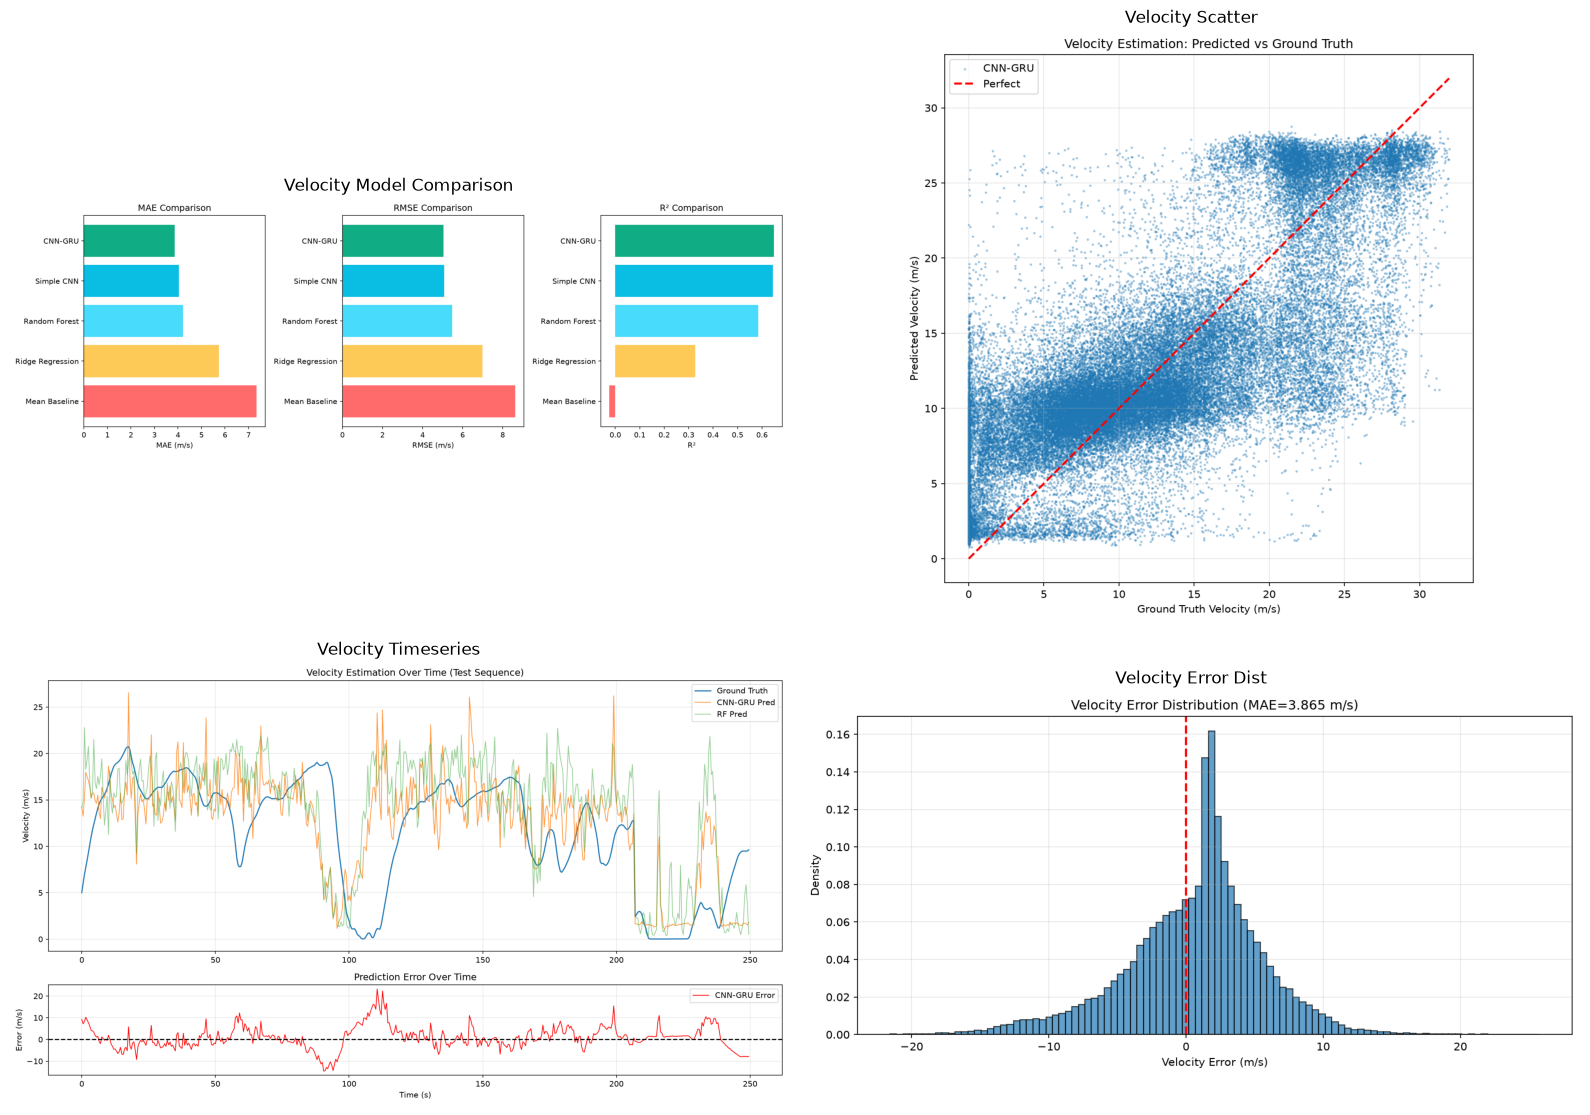

In [6]:
fig_files = [
    'velocity_model_comparison.png',
    'velocity_scatter.png',
    'velocity_timeseries.png',
    'velocity_error_dist.png'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, fname in zip(axes.flatten(), fig_files):
    img_path = FIGURES_DIR / fname
    if img_path.exists():
        img = plt.imread(img_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(fname.replace('.png', '').replace('_', ' ').title(), fontsize=12)
plt.tight_layout()
plt.show()

### 6. TFLite Edge Deployment & Inference Latency
Verify the quantized TFLite model runs using pure built-in operators with sub-millisecond execution time.

In [7]:
tflite_path = MODELS_DIR / "velocity" / "velocity_cnn_gru.tflite"
interp = tf.lite.Interpreter(model_path=str(tflite_path))
interp.allocate_tensors()

in_idx = interp.get_input_details()[0]['index']
out_idx = interp.get_output_details()[0]['index']

dummy_input = np.zeros((1, 10, 6), dtype=np.float32)
latencies = []
for _ in range(100):
    t0 = time.perf_counter()
    interp.set_tensor(in_idx, dummy_input)
    interp.invoke()
    _ = interp.get_tensor(out_idx)
    latencies.append((time.perf_counter() - t0) * 1000)

print(f"TFLite Model File:    {tflite_path.name} ({tflite_path.stat().st_size/1024:.1f} KB)")
print(f"Average CPU Latency:  {np.mean(latencies):.3f} ms")
print(f"Throughput:           {1000.0/np.mean(latencies):.0f} predictions/second")

TFLite Model File:    velocity_cnn_gru.tflite (55.1 KB)
Average CPU Latency:  0.009 ms
Throughput:           114551 predictions/second


/home/sibsankar_de/projects/sih_2026/ml_models/venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
